In [1]:
import argparse
import ast
import datetime as dt
import json
import os
import sys
from pathlib import Path
from typing import Dict
from typing import List
from typing import Literal
from typing import Optional
from typing import Tuple
from typing import Union

import numpy as np
import pandas as pd
import rasterio
import torch
from numpy import ndarray
from omegaconf import DictConfig
from omegaconf import OmegaConf
from rasterio.windows import Window
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from tqdm import tqdm
from tqdm.auto import tqdm

from dataloader_CIRCA.tools.data_processor import SentinelDataProcessor
from dataloader_CIRCA.tools.mask_generation import masks_init_filling
from dataloader_CIRCA.tools.positional_encoding import get_position_for_positional_encoding  # NOQA
from lib import config_utils
from lib.arguments import eval_parser
from lib.eval_tools import Imputation
from lib import visutils

ChannelType = Literal["all", "bgr-nir"]
MAX_PIXEL_INTENSITY_USED_FOR_REVERSE = 10_000
GDAL_OPTIONS = {
    "compress": "LZW",
    "tiled": True,
    "blockxsize": 256,
    "blockysize": 256,
    "SPARSE_MODE": False,
}


In [64]:
class TypeConverter:

    def __init__(self):
        self._from = "float32"
        self._to = "uint8"

    def from_type(self, img_type):
        self._from = img_type
        return self

    def to_type(self, img_type):
        self._to = img_type
        return self

    def convert(self, img, threshold=0.5):
        if self._from == "float32":
            if self._to == "float32":
                return img
            elif self._to == "uint8":
                if img.max() > 1:
                    img = img.astype(np.float32) / img.max()  # normalize the data to 0 - 1
                img = 255 * img  # scale by 255
                return img.astype(np.uint8)
            elif self._to == "uint16":
                if img.max() <= 1.0:
                    img = np.iinfo(np.uint16).max * img
                return img.astype(np.uint16)
            elif self._to == "bit":
                img = img > threshold
                return img.astype(np.uint8)
            else:
                return img


class Dataset_from_files(Dataset):
    """
    A custom PyTorch Dataset designed to manage Sentinel-1 and Sentinel-2 data specifically for cloud
    reconstruction tasks.
    """

    def __init__(
        self,
        data_optique: Union[str, Path],
        data_radar: Union[str, Path],
        mgrsc: Optional[str],
        image_size: Tuple = (256, 256),
        overlap: Optional[int] = 0,
        load_dataset: Optional[str] = None,
        shuffle: bool = False,
        use_sar: bool = "mix_closest",
        no_filter: bool = False,
        channels: ChannelType = "all",
        pe_strategy: str = "day-within-sequence",
    ):
        """
        Initializes the dataset.

        Parameters:
        - data_optique (Union[str, Path]): Path to the optical data directory.
        - data_radar (Union[str, Path]): Path to the radar data directory.
        - image_size (int, optional): Size of the patches to extract. Defaults to 256.
        - overlap (int, optional): Number of pixels to overlap between patches on all sides. Defaults to 0.
        - load_dataset (Optional[str], optional): Path to a pre-saved dataset CSV file. Defaults to None.
        - shuffle (bool, optional): Whether to shuffle the dataset. Defaults to False.
        - use_sar (bool, optional): Whether to include SAR data in the dataset. Defaults to True.
        """
        self.data_optique = Path(data_optique)
        self.data_radar = Path(data_radar)
        self.mgrsc = mgrsc
        self.image_size = (image_size, image_size) if isinstance(image_size, int) else image_size
        self.overlap = overlap
        self.load_dataset = load_dataset
        self.shuffle = shuffle
        self.zones_dataset, self.dates_dict = None, None
        self.patches_dataset = None
        self.use_sar = use_sar
        self.no_filter = no_filter
        self.num_channels, self.c_index_rgb, self.c_index_nir, self.s2_channels = self.setup_channels(channels)
        self.s2_tile = None
        self.s1_asc_tile = None
        self.s1_desc_tile = None
        self.pe_strategy = pe_strategy
        self.setup()

    def __len__(self) -> int:
        """
        Returns the number of patches in the dataset.

        Returns:
        - int: Number of patches.
        """
        return len(self.mgrsc_dataset)

    def setup(self, load_dataset: Optional[str] = None) -> None:
        """
        Sets up the dataset by either loading from a pre-saved file or processing the data.

        Parameters:
        - load_dataset (Optional[str], optional): Path to a pre-saved dataset CSV file. Defaults to None.
        """
        if self.load_dataset is not None or load_dataset is not None:
            self.load_exported_data(load_dataset or self.load_dataset)
        else:
            self.setup_zones()
            self.setup_patches()

        if self.shuffle:
            self.patches_dataset = self.patches_dataset.sample(frac=1).reset_index(drop=True)

        self.setup_mgrsc_parameters()
        self.setup_mgrsc_files()
        if self.use_sar:
            self.setup_s1_dates()

    def setup_channels(self, channels: ChannelType) -> Tuple[int, torch.Tensor, torch.Tensor, List[int]]:
        """
        Configure channel settings based on the specified channel mode.

        Args:
            channels: Channel configuration ('all' or 'bgr-nir')

        Returns:
            Tuple containing:
            - Number of channels
            - RGB channel indices tensor
            - NIR channel index tensor
            - List of Sentinel-2 channel indices

        Raises:
            ValueError: If invalid channel configuration is specified
        """
        if channels == "all":
            num_channels = 10
            c_index_rgb = torch.tensor([2, 1, 0], dtype=torch.long)
            c_index_nir = torch.tensor([6], dtype=torch.long)
            s2_channels = list(range(10))
        elif channels == "bgr-nir":
            num_channels = 4
            c_index_rgb = torch.tensor([2, 1, 0], dtype=torch.long)
            c_index_nir = torch.tensor([6], dtype=torch.long)
            s2_channels = [0, 1, 2, 6]
        else:
            raise ValueError(f"Channels {channels} not recognized. Use 'all' or 'bgr-nir'.")

        if self.use_sar:
            if self.use_sar == "asc+desc":
                num_channels += 8
            elif self.use_sar == "asc" or self.use_sar == "desc" or self.use_sar == "mix_closest":
                num_channels += 4
            else:
                raise ValueError(
                    f"SAR pairing {self.use_sar} not recognized. Use 'asc+desc', 'asc', 'desc' or 'mix_closest'."
                )
        return num_channels, c_index_rgb, c_index_nir, s2_channels

    def setup_mgrsc_parameters(self: Optional[str]) -> None:
        """
        Sets up parameters specific to a given MGRS-C area.

        Parameters:
        - mgrsc (Optional[str]): The MGRS-C area identifier.
        """
        if self.mgrsc is None:
            raise ValueError("MGRS-C area must be specified for this operation.")
        # Implement any specific setup required for the given MGRS-C area
        self.mgrsc_dataset = (
            self.patches_dataset[self.patches_dataset["mgrs25"] == self.mgrsc].copy().reset_index(drop=True)
        )
        self.dates_s2 = np.array([self.str2date(date) for date in self.dates_dict[self.mgrsc]["S2"]])
        # Extract the number of days since the first observation in the sequence (= temporal sampling)
        self.days = get_position_for_positional_encoding(self.dates_s2, "day-within-sequence")
        # Get positions for positional encoding
        self.position_days = get_position_for_positional_encoding(self.dates_s2, self.pe_strategy)

    def setup_mgrsc_files(self) -> None:
        # listage des fichiers à utiliser pour itérer sur les patchs contenus dans la zone MGRS-C
        files = set([el for sublist in self.mgrsc_dataset["files"].tolist() for el in sublist])
        if self.use_sar:
            assert len(files) == 3, "Expected exactly 3 files (S2, S1_ASC, S1_DESC) for the MGRS-C area."
        else:
            assert len(files) == 1, "Expected exactly 1 file (S2) for the MGRS-C area."
        self.s2_file = [f for f in files if "ASC" not in f and "DESC" not in f][0]
        if self.use_sar:
            self.s1_asc_file = [f for f in files if "ASC" in f][0]
            self.s1_desc_file = [f for f in files if "DESC" in f][0]
        with rasterio.open(self.s2_file) as src:
            self.s2_meta = src.meta.copy()
        if self.use_sar:
            with rasterio.open(self.s1_asc_file) as src:
                self.s1_asc_meta = src.meta.copy()
            with rasterio.open(self.s1_desc_file) as src:
                self.s1_desc_meta = src.meta.copy()

    def setup_s1_dates(self) -> None:
        self.dates_s1_asc = self.dates_dict[self.mgrsc]["S1"]["ASC"]
        self.dates_s1_desc = self.dates_dict[self.mgrsc]["S1"]["DESC"]
        self.closest_dates_matches = SentinelDataProcessor.get_pairedS1_closest_matches(
            dates_S2=self.dates_s2,
            dates_S1_asc=self.dates_s1_asc,
            dates_S1_desc=self.dates_s1_desc,
        )

    def load_exported_data(self, path_data: Union[str, Path]) -> None:
        """
        Loads the dataset from a pre-saved CSV file.

        Parameters:
        - path_data (Union[str, Path]): Path to the CSV file.
        """
        self.patches_dataset = pd.read_csv(path_data)
        cols_to_convert = [
            "window",
            "files",
            "dates_S2",
            "dates_S1_ASC",
            "dates_S1_DESC",
        ]
        self.patches_dataset[cols_to_convert] = self.patches_dataset[cols_to_convert].map(ast.literal_eval)

        if (
            self.patches_dataset.loc[0, "window"][2] != self.image_size[0]
            and self.patches_dataset.loc[0, "window"][3] != self.image_size[1]
        ):
            print(
                """
                WARNING : Patch size load in the .csv file is not corresponding to the patch size requested 
                during the dataset initialization. New setup of the dataset will be done.."
                """
            )
            self.setup()

        # Recreate the dates dictionary after loading
        self.dates_dict = {
            mgrs25: {
                "S2": self.patches_dataset[self.patches_dataset["mgrs25"] == mgrs25]["dates_S2"].values[0],
                "S1": {
                    "ASC": self.patches_dataset[self.patches_dataset["mgrs25"] == mgrs25]["dates_S1_ASC"].values[0],
                    "DESC": self.patches_dataset[self.patches_dataset["mgrs25"] == mgrs25]["dates_S1_DESC"].values[0],
                },
            }
            for mgrs25 in self.patches_dataset["mgrs25"].unique()
        }

    def setup_patches(self) -> None:
        """
        Sets up the patches by processing the data and creating a DataFrame.
        """
        self.patches_dataset = pd.DataFrame(columns=["patch", "window", "mgrs", "mgrs25", "files"]).astype(object)

        for _, row in tqdm(self.zones_dataset.iterrows(), total=len(self.zones_dataset), leave=False):
            for window in row.windows:
                windows_str = "_".join(map(str, window))
                patch_df = pd.DataFrame(
                    {
                        "patch": f"patches_{row.mgrs25}_window_{windows_str}",
                        "window": [window],
                        "mgrs": row.mgrs,
                        "mgrs25": row.mgrs25,
                        "files": [row.files],  # 0: S2, 1: S1_ASC, 2: S1_DESC
                        "dates_S2": [row.dates_S2],
                        "dates_S1_ASC": [row.dates_S1_ASC],
                        "dates_S1_DESC": [row.dates_S1_DESC],
                    }
                )
                self.patches_dataset = pd.concat([self.patches_dataset, patch_df], ignore_index=True)

    def setup_zones(self) -> None:
        """
        Sets up the zones by processing the data and creating a DataFrame.
        """
        self.zones_dataset = pd.DataFrame(columns=["mgrs", "mgrs25", "files", "windows"]).astype(object)
        self.dates_dict = {}

        for mgrs in tqdm(list(self.data_optique.iterdir()), leave=False, desc="mgrs"):
            for mgrs25 in tqdm(list(mgrs.iterdir()), leave=False, desc="mgrs25"):
                self.process_mgrs25_zone(mgrs, mgrs25)

    def process_mgrs25_zone(self, mgrs: Path, mgrs25: Path) -> None:
        """
        Processes a single MGRS25 zone.

        Parameters:
        - mgrs (Path): Path to the MGRS zone.
        - mgrs25 (Path): Path to the MGRS25 zone.
        """
        mgrs_name = mgrs.stem
        mgrs25_name = mgrs25.stem[7:]
        self.dates_dict[mgrs25_name] = {}

        # Process Sentinel-2 data
        list_tifs_optique = sorted(mgrs25.rglob("*.tif"))
        list_jsons_optique = sorted(mgrs25.rglob("*.json"))
        dates_S2 = json.load(open(list_jsons_optique[0]))
        self.dates_dict[mgrs25_name]["S2"] = dates_S2

        # Process Sentinel-1 data
        mgrs25_radar = self.data_radar / mgrs_name / ("MGRS25-" + mgrs25_name)
        assert mgrs25_radar.exists()

        list_tifs_radar = sorted(mgrs25_radar.rglob("*.tif"))
        list_jsons_radar = sorted(mgrs25_radar.rglob("*.json"))

        tif_files = {"S2": list_tifs_optique[0]}
        for file in list_tifs_radar:
            if file.stem.endswith("ASC"):
                tif_files["S1_ASC"] = file
            else:
                tif_files["S1_DESC"] = file

        list_windows = SentinelDataProcessor.split_raster_into_windows(
            path_raster=tif_files["S2"],
            image_size=self.image_size,
            overlap=self.overlap,
        )

        self.dates_dict[mgrs25_name]["S1"] = {
            file.stem.split("_")[-1]: json.load(open(file)) for file in list_jsons_radar
        }

        data = {
            "mgrs": mgrs_name,
            "mgrs25": mgrs25_name,  # Remove the 'MGRS25-' prefix
            "files": [sorted(f.as_posix() for f in tif_files.values())],
            "windows": [list_windows],
            "dates_S2": [dates_S2],
            "dates_S1_ASC": [self.dates_dict[mgrs25_name]["S1"]["ASC"]],
            "dates_S1_DESC": [self.dates_dict[mgrs25_name]["S1"]["DESC"]],
        }
        df_temp = pd.DataFrame(data).astype(object)
        self.zones_dataset = pd.concat([self.zones_dataset, df_temp], ignore_index=True)

    def export_dataset(self, outpath: Union[str, Path] = "tiles_windows.csv") -> None:
        """
        Exports the dataset to a CSV file.

        Parameters:
        - outpath (Union[str, Path], optional): Path to save the CSV file. Defaults to "datasetCIRCAUnCRtainTS.csv".
        """
        self.patches_dataset.to_csv(outpath, index=False)

    def str2date(self, date_string: str) -> dt.date:
        """
        Convert a date string in format 'YYYYMMDD' to datetime object.

        Args:
            date_string: Date string in format 'YYYYMMDD'

        Returns:
            Corresponding datetime.date object

        Example:
            >>> str2date("20200101")
            datetime.date(2020, 1, 1)
        """
        return dt.datetime.strptime(date_string, "%Y%m%d")

    def decode_dates(self, dates: ndarray[np.bytes_]) -> List[str]:
        """
        Decode byte strings in date array to UTF-8 strings.

        Args:
            dates: Array of date byte strings

        Returns:
            List of decoded date strings
        """
        return [el.decode("utf-8") for el in dates]

    def __getitem__(self, item: int) -> Dict[str, Union[np.ndarray, str, List[str]]]:
        """
        Retrieves an item from the dataset.

        Parameters:
        - item (int): Index of the item to retrieve.

        Returns:
        - Dict[str, Union[np.ndarray, str, List[str]]]: A dictionary containing the data, name, masks, and dates.
        """
        patch_data = self.mgrsc_dataset.iloc[item]
        patch_S2_array = torch.from_numpy(
            SentinelDataProcessor.read_MS(
                self.s2_file,
                window=Window(*patch_data.window),
                return_meta=False,
            ).astype(np.float32)
        )  # Extraction données S2

        # patch_S2_array = self.s2_tile[:, :, y : y + h, x : x + w]  # Extraction données S2
        # Pas de filtrage sur les dates sur les données s2
        data_s2 = patch_S2_array[:, 0:10, ...]
        patch_S2_array[:, 10, ...] = patch_S2_array[:, 10, ...]  # cloud mask synthetic data

        data_s2 = SentinelDataProcessor.process_MS(data_s2)
        # faire une récupération des données synthétiques
        original_masks = patch_S2_array[:, 10:, ...]
        cloud_probs = original_masks[:, 0, ...].clone().unsqueeze(axis=1)
        cloud_masks = (cloud_probs > 0).float()  # Binarization of cloud masks

        if self.use_sar:
            s1_tile_asc = SentinelDataProcessor.read_SAR(
                self.s1_asc_file,
                window=Window(*patch_data.window),
                return_meta=False,
            )  # T x 4 x H x W
            s1_tile_desc = SentinelDataProcessor.read_SAR(
                self.s1_desc_file,
                window=Window(*patch_data.window),
                return_meta=False,
            )  # T x 4 x H x W
            s1_tile, s1_dates = [], []
            for index_s2, (date_s2, date_s1, index_s1, orbit_type) in enumerate(self.closest_dates_matches):
                if orbit_type == "ASC":
                    s1_band = s1_tile_asc[index_s1, ...].copy()
                else:
                    s1_band = s1_tile_desc[index_s1, ...].copy()
                s1_tile.append(s1_band)
                s1_dates.append(date_s1)

            s1_tile = np.stack(s1_tile, axis=0)
            s1_tile = torch.from_numpy(s1_tile.astype(np.float32))
            dates_s1 = np.array([self.str2date(date) for date in s1_dates])
            data_s1 = SentinelDataProcessor.process_SAR(s1_tile)

        # Ajout des masques de nuages originaux dans l'input
        # Image time series with overlaid cloud masks filled with value `fill_value`
        images_masked, masks = masks_init_filling(
            seq=data_s2.clone(),
            masks=cloud_masks,
            fill_type="fill_value",
            fill_value=config.mask.fill_value,
            dilate_cloud_masks=False,
        )

        if self.use_sar:
            frames_input = torch.cat((data_s2.clone(), data_s1), dim=1)
        else:
            frames_input = data_s2.clone()

        masks = cloud_masks
        frames_target = data_s2.clone()

        masks_valid_obs = torch.ones(frames_input.shape[0], dtype=torch.uint8)

        out = {
            "x": frames_input,  # (synthetically masked) S2 TS, (T x C x H x W), optionally including S1.
            "y": frames_target,  # observed/target satellite image time series, (T x C x H x W)
            "masks": masks,  # masks applied to `x`, (T x 1 x H x W); pixel with value 1 is masked, 0 otherwise
            "masks_valid_obs": masks_valid_obs,  # flag to indicate valid time steps, (T, ); 1 if valid, 0 if invalid
            "position_days": self.position_days,
            "days": self.days,  # temporal sampling, number of days since the first observation in the sequence, (T, )
            "sample_index": item,
            "c_index_rgb": self.c_index_rgb,
            "c_index_nir": self.c_index_nir,
            "S2_dates": [date.strftime("%Y-%m-%d") for date in self.dates_s2],
            "original_masks": original_masks,
            "cloud_mask": cloud_masks,
            "window": patch_data["window"],
        }
        if self.use_sar:
            out["S1_dates"] = [date.strftime("%Y-%m-%d") for date in dates_s1]
        return out

In [65]:
args, unknown = eval_parser.parse_known_args(args=['./configs/config_run_inference.yaml', 'utilise'])

In [66]:
config = config_utils.read_config(args.config_file)
if "test_data" in config:
    temp = OmegaConf.create()
    temp.config_file = args.config_file
    temp.method = args.method
    temp.test_data = config.test_data
    if "mode" in temp.test_data:
        temp.mode = config.test_data.mode
    if "checkpoint" in temp.test_data:
        temp.checkpoint = config.test_data.checkpoint
        del temp.test_data.checkpoint
    if "return_predictions" in temp.test_data:
        temp.return_predictions = config.test_data.return_predictions
        del temp.test_data.return_predictions
    if "predictions_save_path" in temp.test_data:
        temp.predictions_save_path = config.test_data.predictions_save_path
        del temp.test_data.predictions_save_path
    args = temp

# Extract settings w.r.t. test data
if args.test_data.test_config is not None:
    if not os.path.isfile(args.test_data.test_config):
        raise FileNotFoundError(f"Cannot find the test configuration file: {args.test_data.test_config}\n")
    test_config = config_utils.read_config(args.test_data.test_config)
    args_test_data = test_config.data
else:
    args_test_data = OmegaConf.create()

if args.test_data.hdf5_file is not None:
    args_test_data.hdf5_file = args.test_data.hdf5_file
if args.test_data.split is not None:
    args_test_data.split = args.test_data.split
if args.test_data.mode is not None:
    args_test_data.mode = args.test_data.mode

In [67]:
args

{'config_file': './configs/config_run_inference.yaml', 'method': 'utilise', 'test_data': {'test_config': '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/config.yaml', 'hdf5_file': '/DATA_10TB/data_rpg/circa/hdf5/CIRCA_CR_merged.hdf5', 'mode': None, 'split': 'test'}, 'mode': None, 'checkpoint': '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth'}

In [68]:
args_test_data

{'filter_settings': {'type': 'cloud-free', 'min_length': 5, 'return_valid_obs_only': True}, 'crop_settings': {'enabled': False, 'shape': '${tuple:64,64}'}, 'pe_strategy': 'day-of-year', 'max_seq_length': 10, 'render_occluded_above_p': 0.9, 'return_cloud_mask': True, 'dataset': 'circa', 'hdf5_file_read': '/var/data/datasets/circa_cloud_removal.hdf5', 'channels': 'all', 'include_S1': True, 'image_size': [256, 256], 'hdf5_file': '/DATA_10TB/data_rpg/circa/hdf5/CIRCA_CR_merged.hdf5', 'split': 'test'}

In [69]:
# def main(
#     args: argparse.Namespace,
#     args_test_data: DictConfig,
# ):
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
_ = torch.set_grad_enabled(False)
if not os.path.isfile(args.config_file):
    raise FileNotFoundError(f"Cannot find the configuration file used during training: {args.config_file}\n")
# Read config file used during training
config = config_utils.read_config(args.config_file)
# Merge generic data settings (used during training) with test-specific data settings
if config.data.get("hdf5_file", False):
    for key in ["hdf5_file", "hdf5_file_read"]:
        if key in args_test_data:
            args_test_data.pop(key)
    args_test_data.hdf5_file = config.data.hdf5_file
# Manage old config settings
if "include_S1" in args_test_data:
    if args_test_data.include_S1 is True:
        config.data.use_sar = "mix_closest"
    else:
        config.data.use_sar = False
    args_test_data.pop("include_S1")
config.data.update(args_test_data)
# Evaluate the entire image sequence (dans le cas de l'evaluation)
config.data.max_seq_length = None
# Define paths
store_dai = Path(config.output.store_dai)
print(store_dai.as_posix())
path_dataset_circa = store_dai / "projets/pac/3str/EXP_2/Data_Raster"
data_optique = path_dataset_circa / "optique_dataset"
data_radar = path_dataset_circa / "radar_dataset_v4"
path_test_set_mgrs25 = store_dai / "projets/pac/3str/EXP_2/train_val_test/MGRSC_test.json"

image_size = [256, 256]
OVERLAP = 0

# CONFIGURATION CRITIQUE pour les workers sur stockage réseau :
# 1. Empêche GDAL d'essayer d'écrire des fichiers de métadonnées (.aux.xml)
os.environ["GDAL_PAM_ENABLED"] = "NO"
# 2. Empêche GDAL de scanner tout le dossier à chaque ouverture
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

# AMÉLIORATION : Plus de workers pour charger les données en parallèle pendant le calcul GPU
num_workers = config.misc.num_workers  # Essayez 4 ou 8 selon votre CPU
pin_memory = torch.cuda.is_available()  # Accélère le transfert vers le GPU
test_mgrs25 = json.load(open(path_test_set_mgrs25))

# Get the imputation model
imputation = Imputation(
    config_file_train=args.config_file,
    method=args.method,
    mode=args.mode,
    checkpoint=args.checkpoint,
    config_file_test=args.test_data.test_config,
    # temporal_window=MAX_SAMPLES_ON_GPU,
    device=device,
)

/mnt/stores/store-dai
Loaded transforms from ./data/CIRCA_patches_datasets_with_transforms.json.
Checkpoint '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth' loaded.
Chosen epoch: 109



In [70]:
mgrs25 = test_mgrs25[0]
output_folder = Path(config.output.save_dir)
output_folder.mkdir(parents=True, exist_ok=True)
out_filename = output_folder / f"pred_mgrsc_{mgrs25}.tif"
if out_filename.exists():
    print(f"Predictions for MGRS-C area {mgrs25} already exist. Skipping...")
else:
    print(f"Writing predictions incrementally to {out_filename}")

ds = Dataset_from_files(
    mgrsc=mgrs25,
    data_optique=data_optique,
    data_radar=data_radar,
    image_size=image_size,
    overlap=OVERLAP,
    # load_dataset=load_dataset,
)
meta = ds.s2_meta.copy()
T, H, W = meta["count"] // 12, meta["height"], meta["width"]
output_type = meta["dtype"]
mgrs25_dataloader = DataLoader(ds, batch_size=1, shuffle=False, pin_memory=pin_memory, num_workers=num_workers)

from rasterio.windows import Window

Predictions for MGRS-C area 31TFJ_row-2_col-3 already exist. Skipping...


mgrs:   0%|          | 0/35 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/2 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

...

mgrs25:   0%|          | 0/1 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/3 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/1 [00:00<?, ?it/s]

mgrs25:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

In [79]:
batch["x"][0, :, -4, ...]

tensor([[[0.3522, 0.4745, 0.0783,  ..., 0.3598, 0.2871, 0.7485],
         [0.4023, 0.6481, 0.2975,  ..., 0.5515, 0.2822, 0.5244],
         [0.4818, 0.7515, 0.3441,  ..., 0.6334, 0.3630, 0.3892],
         ...,
         [0.2843, 0.3651, 0.5137,  ..., 0.0000, 0.4907, 0.5927],
         [0.3139, 0.3924, 0.7145,  ..., 0.0000, 0.6050, 0.8062],
         [0.5323, 0.4348, 0.7588,  ..., 0.5042, 0.6905, 0.7480]],

        [[0.3522, 0.4745, 0.0783,  ..., 0.3598, 0.2871, 0.7485],
         [0.4023, 0.6481, 0.2975,  ..., 0.5515, 0.2822, 0.5244],
         [0.4818, 0.7515, 0.3441,  ..., 0.6334, 0.3630, 0.3892],
         ...,
         [0.2843, 0.3651, 0.5137,  ..., 0.0000, 0.4907, 0.5927],
         [0.3139, 0.3924, 0.7145,  ..., 0.0000, 0.6050, 0.8062],
         [0.5323, 0.4348, 0.7588,  ..., 0.5042, 0.6905, 0.7480]],

        [[0.3522, 0.4745, 0.0783,  ..., 0.3598, 0.2871, 0.7485],
         [0.4023, 0.6481, 0.2975,  ..., 0.5515, 0.2822, 0.5244],
         [0.4818, 0.7515, 0.3441,  ..., 0.6334, 0.3630, 0.

In [71]:
converter = TypeConverter()
batch = next(iter(mgrs25_dataloader))
batch, y_pred = imputation.impute_sample(batch)

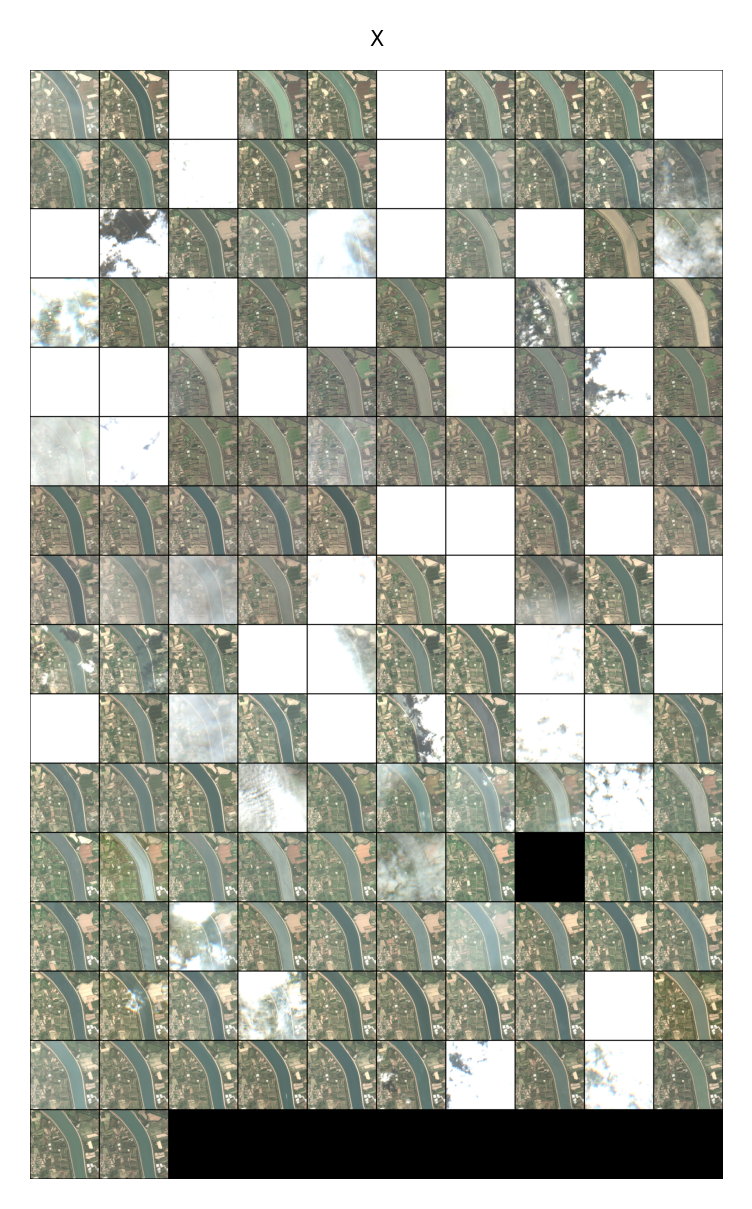

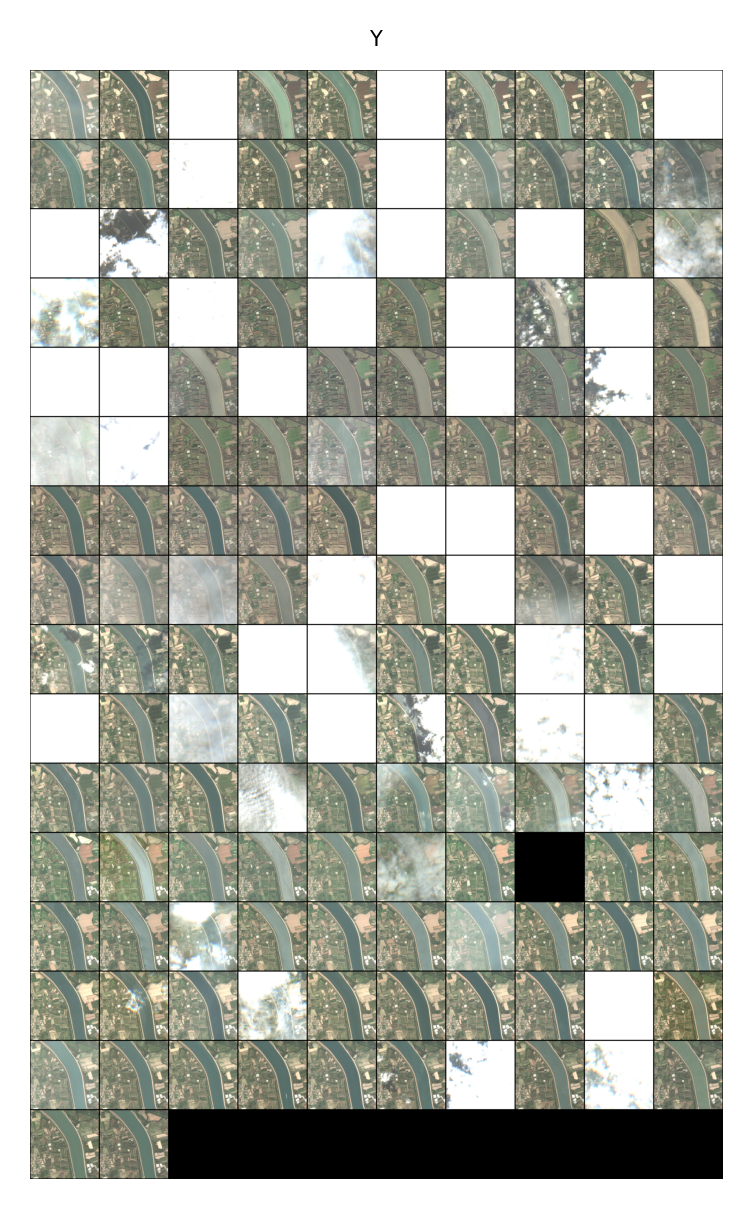

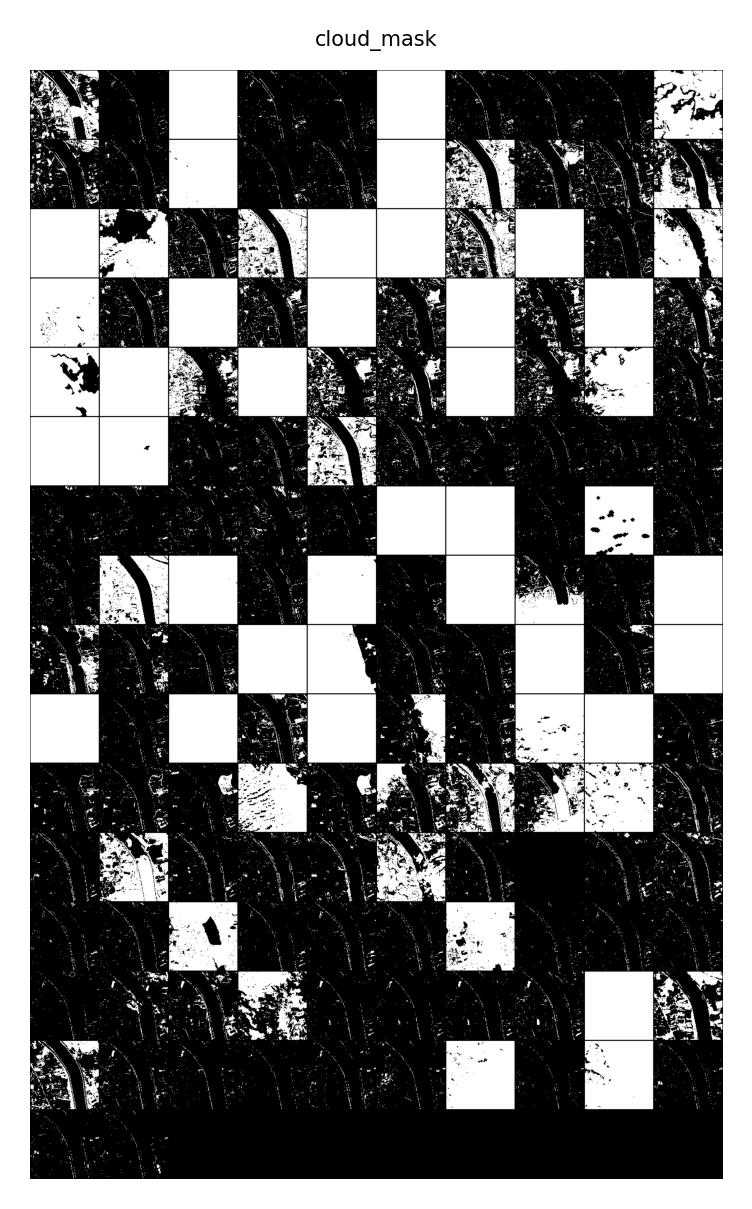

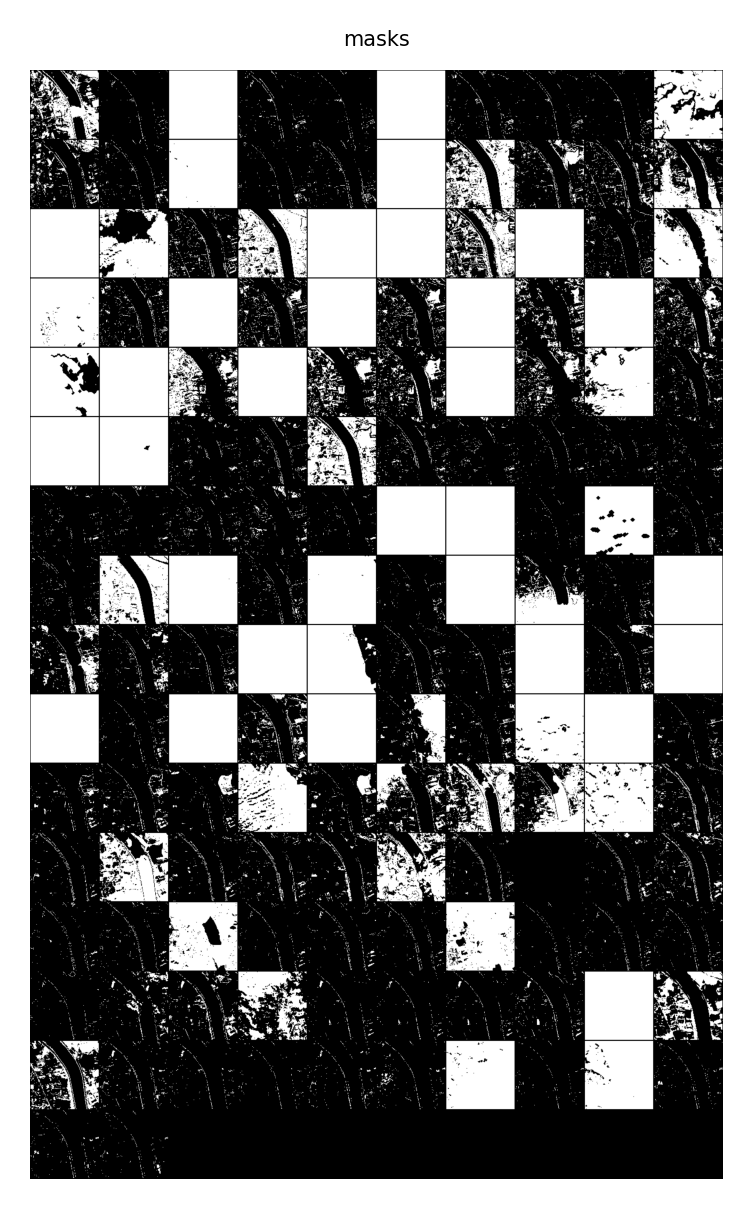

In [57]:
import matplotlib.pyplot as plt
from lib import visutils
BRIGHTNESS_FACTOR = 3

fig = visutils.sequence2gallery(
    batch['x'][0][:, :10, ...], 
    indices_rgb=batch['c_index_rgb'][0], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f"X", fontsize=5)

fig = visutils.sequence2gallery(
    batch['y'][0], 
    indices_rgb=batch['c_index_rgb'][0], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f"Y", fontsize=5)

# Afficahge cloud mask d'origine contenant les pixels nuageux que l'on ne va pas considérer
fig = visutils.sequence2gallery(
    batch['cloud_mask'][0],
    variable='binary_mask',
    indices_rgb=batch["c_index_nir"][0], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f"cloud_mask", fontsize=5)

# Afficahge cloud mask d'origine contenant les pixels nuageux que l'on ne va pas considérer
fig = visutils.sequence2gallery(
    batch['masks'][0],
    variable='binary_mask',
    indices_rgb=batch["c_index_nir"][0], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f"masks", fontsize=5)
plt.show()

In [61]:
y_pred

tensor([[[[[0.2263, 0.2341, 0.2838,  ..., 0.2130, 0.2120, 0.2112],
           [0.2242, 0.2341, 0.2845,  ..., 0.2138, 0.2123, 0.2135],
           [0.2169, 0.2260, 0.2803,  ..., 0.2150, 0.2128, 0.2118],
           ...,
           [0.1733, 0.1726, 0.1692,  ..., 0.1846, 0.1875, 0.1867],
           [0.1748, 0.1743, 0.1677,  ..., 0.1837, 0.1846, 0.1849],
           [0.1755, 0.1761, 0.1683,  ..., 0.1832, 0.1856, 0.1844]],

          [[0.2611, 0.2606, 0.3109,  ..., 0.2449, 0.2453, 0.2477],
           [0.2650, 0.2666, 0.3150,  ..., 0.2463, 0.2465, 0.2466],
           [0.2560, 0.2535, 0.3103,  ..., 0.2486, 0.2477, 0.2470],
           ...,
           [0.2044, 0.2060, 0.2019,  ..., 0.2201, 0.2243, 0.2238],
           [0.2069, 0.2078, 0.2003,  ..., 0.2201, 0.2217, 0.2210],
           [0.2103, 0.2121, 0.2031,  ..., 0.2171, 0.2194, 0.2193]],

          [[0.2660, 0.2700, 0.3249,  ..., 0.2556, 0.2564, 0.2556],
           [0.2699, 0.2736, 0.3278,  ..., 0.2595, 0.2569, 0.2577],
           [0.2568, 0.2595

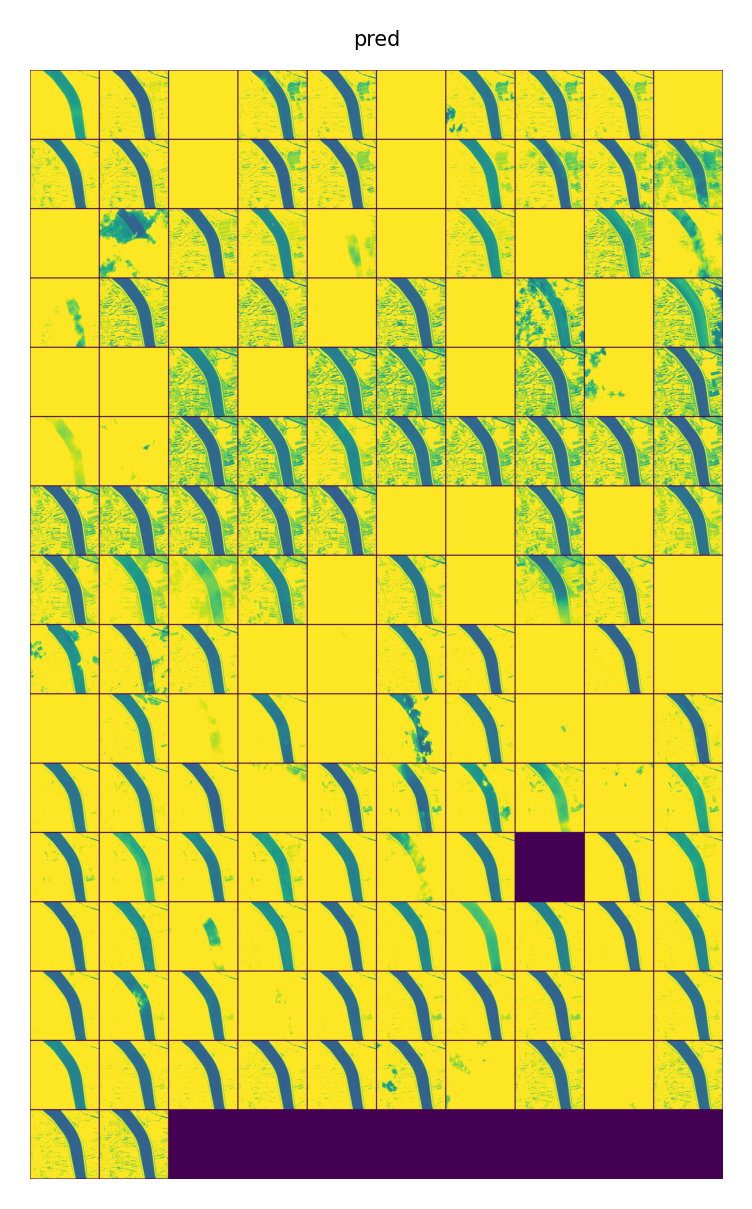

In [63]:
fig = visutils.sequence2gallery(
    y_pred[0],
    indices_rgb=batch["c_index_nir"][0], 
    brightness_factor=BRIGHTNESS_FACTOR,
)
plt.title(f"pred", fontsize=5)
plt.show()


In [14]:
x, y, h, w = (
    batch["window"][0].item(),
    batch["window"][1].item(),
    batch["window"][2].item(),
    batch["window"][3].item(),
)

# Reverse normalization
denorm_pred = SentinelDataProcessor.reverse_process_MS(
    y_pred, intensity_max=MAX_PIXEL_INTENSITY_USED_FOR_REVERSE
)

# 1. Get prediction (T, 10, h, w) on CPU
pred_patch = denorm_pred.squeeze(axis=0).cpu().numpy()

# 2. Get original bands 11 & 12 (T, 2, h, w) from the batch
original_bands = batch["original_masks"].squeeze(axis=0).cpu().numpy()  # (T, 2, h, w)

# 3. Concatenate (T, 12, h, w)
full_patch = np.concatenate([pred_patch, original_bands], axis=1)

# 4. Reshape to flattened channels (T*12, h, w)
full_patch = full_patch.reshape(
    full_patch.shape[0] * full_patch.shape[1], full_patch.shape[2], full_patch.shape[3]
)

# 5. Convert to uint16
final_patch = converter.from_type("float32").to_type(output_type).convert(full_patch)

In [15]:
with rasterio.open(out_filename, "w", **meta, **GDAL_OPTIONS) as dst:
    converter = TypeConverter()
    with torch.no_grad():  # Envelopper la boucle
        for batch in tqdm(mgrs25_dataloader, leave=False, total=len(ds), desc="Patches"):
            batch, y_pred = imputation.impute_sample(batch)
            x, y, h, w = (
                batch["window"][0].item(),
                batch["window"][1].item(),
                batch["window"][2].item(),
                batch["window"][3].item(),
            )
            # Reverse normalization
            denorm_pred = SentinelDataProcessor.reverse_process_MS(
                y_pred, intensity_max=MAX_PIXEL_INTENSITY_USED_FOR_REVERSE
            )

            # 1. Get prediction (T, 10, h, w) on CPU
            pred_patch = denorm_pred.squeeze(axis=0).cpu().numpy()

            # 2. Get original bands 11 & 12 (T, 2, h, w) from the batch
            original_bands = batch["original_masks"].squeeze(axis=0).cpu().numpy()  # (T, 2, h, w)

            # 3. Concatenate (T, 12, h, w)
            full_patch = np.concatenate([pred_patch, original_bands], axis=1)

            # 4. Reshape to flattened channels (T*12, h, w)
            full_patch = full_patch.reshape(
                full_patch.shape[0] * full_patch.shape[1], full_patch.shape[2], full_patch.shape[3]
            )

            # 5. Convert to uint16
            final_patch = converter.from_type("float32").to_type(output_type).convert(full_patch)

            # 6. Write directly to disk
            dst.write(final_patch, window=Window(x, y, w, h))

    print(f"Predictions for MGRS-C area {mgrs25} saved successfully.")
    print(f"File path: {out_filename.as_posix()}")
    print("-----------------------------------------------------")

print("Inference completed.")

SyntaxError: invalid syntax (943018855.py, line 2)

In [ ]:
# load_dataset = config.output.get("tiles_window_file", None)
for mgrs25 in tqdm(test_mgrs25, desc="MGRS-C areas"):
    output_folder = Path(config.output.save_dir)
    output_folder.mkdir(parents=True, exist_ok=True)
    out_filename = output_folder / f"pred_mgrsc_{mgrs25}.tif"
    if out_filename.exists():
        print(f"Predictions for MGRS-C area {mgrs25} already exist. Skipping...")
        continue
    else:
        print(f"Writing predictions incrementally to {out_filename}")

    ds = Dataset_from_files(
        mgrsc=mgrs25,
        data_optique=data_optique,
        data_radar=data_radar,
        image_size=image_size,
        overlap=OVERLAP,
        # load_dataset=load_dataset,
    )
    meta = ds.s2_meta.copy()
    T, H, W = meta["count"] // 12, meta["height"], meta["width"]
    output_type = meta["dtype"]
    mgrs25_dataloader = DataLoader(ds, batch_size=1, shuffle=False, pin_memory=pin_memory, num_workers=num_workers)

    from rasterio.windows import Window

    with rasterio.open(out_filename, "w", **meta, **GDAL_OPTIONS) as dst:
        converter = TypeConverter()

        with torch.no_grad():  # Envelopper la boucle
            for batch in tqdm(mgrs25_dataloader, leave=False, total=len(ds), desc="Patches"):
                batch, y_pred = imputation.impute_sample(batch)
                x, y, h, w = (
                    batch["window"][0].item(),
                    batch["window"][1].item(),
                    batch["window"][2].item(),
                    batch["window"][3].item(),
                )
                # Reverse normalization
                denorm_pred = SentinelDataProcessor.reverse_process_MS(
                    y_pred, intensity_max=MAX_PIXEL_INTENSITY_USED_FOR_REVERSE
                )

                # 1. Get prediction (T, 10, h, w) on CPU
                pred_patch = denorm_pred.squeeze(axis=0).cpu().numpy()

                # 2. Get original bands 11 & 12 (T, 2, h, w) from the batch
                original_bands = batch["original_masks"].squeeze(axis=0).cpu().numpy()  # (T, 2, h, w)

                # 3. Concatenate (T, 12, h, w)
                full_patch = np.concatenate([pred_patch, original_bands], axis=1)

                # 4. Reshape to flattened channels (T*12, h, w)
                full_patch = full_patch.reshape(
                    full_patch.shape[0] * full_patch.shape[1], full_patch.shape[2], full_patch.shape[3]
                )

                # 5. Convert to uint16
                final_patch = converter.from_type("float32").to_type(output_type).convert(full_patch)

                # 6. Write directly to disk
                dst.write(final_patch, window=Window(x, y, w, h))

        print(f"Predictions for MGRS-C area {mgrs25} saved successfully.")
        print(f"File path: {out_filename.as_posix()}")
        print("-----------------------------------------------------")

print("Inference completed.")